# Predicting Returning Customers with GA4 Behavioral Data

This notebook builds a machine learning model to predict whether users active in November-December 2020 returned in January 2021. The analysis uses GA4 ecommerce behavioral, recency, traffic source, device, and geography features to score users for potential re-engagement.

In [ ]:
# load libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from google.cloud import bigquery

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
)

In [2]:
# load data from BigQuery

PROJECT_ID = "ga4-ecommerce-portfolio-504020"
client = bigquery.Client(project=PROJECT_ID)
query = """
SELECT *
FROM `ga4-ecommerce-portfolio-504020.ga4_ecommerce.mart_customer_features`
"""
df = client.query(query).to_dataframe()
df.shape

/Users/nikkifackler/Library/CloudStorage/OneDrive-UniversityofNorthCarolinaatChapelHill/Fackler/Git Repos/GA4-Ecommerce-Funnel-Analytics-ML/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(179085, 37)

In [3]:
# inspect data 

df.head()
df.info()   
df["came_back_in_january"].value_counts()
df["came_back_in_january"].value_counts(normalize=True)

<class 'pandas.DataFrame'>
RangeIndex: 179085 entries, 0 to 179084
Data columns (total 37 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   user_pseudo_id                   179085 non-null  str    
 1   first_seen_date                  179085 non-null  dbdate 
 2   last_seen_date                   179085 non-null  dbdate 
 3   days_since_last_seen             179085 non-null  Int64  
 4   customer_span_days               179085 non-null  Int64  
 5   active_days_last_7_days          179085 non-null  Int64  
 6   active_days_last_14_days         179085 non-null  Int64  
 7   events_last_7_days               179085 non-null  Int64  
 8   events_last_14_days              179085 non-null  Int64  
 9   active_days                      179085 non-null  Int64  
 10  total_events                     179085 non-null  Int64  
 11  view_item_events                 179085 non-null  Int64  
 12  add_to_cart_e

came_back_in_january
0    0.979222
1    0.020778
Name: proportion, dtype: Float64

In [ ]:
# inspect missing values

df.isna().sum().sort_values(ascending=False)

In [4]:
# descriptive statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
days_since_last_seen,179085.0,28.162632,16.704506,0.0,15.0,26.0,42.0,60.0
customer_span_days,179085.0,1.055404,4.747729,0.0,0.0,0.0,0.0,60.0
active_days_last_7_days,179085.0,0.106212,0.32778,0.0,0.0,0.0,0.0,6.0
active_days_last_14_days,179085.0,0.235866,0.474595,0.0,0.0,0.0,0.0,9.0
events_last_7_days,179085.0,1.044878,7.489626,0.0,0.0,0.0,0.0,586.0
events_last_14_days,179085.0,2.594288,13.283563,0.0,0.0,0.0,0.0,730.0
active_days,179085.0,1.186593,0.646554,1.0,1.0,1.0,1.0,12.0
total_events,179085.0,17.228897,42.601763,1.0,4.0,5.0,12.0,1309.0
view_item_events,179085.0,1.67014,7.1146,0.0,0.0,0.0,0.0,330.0
add_to_cart_events,179085.0,0.240227,1.919879,0.0,0.0,0.0,0.0,98.0


In [5]:
# separate numeric and categorical columns

numeric_cols = df.select_dtypes(include=["number", "Int64", "float64", "int64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

numeric_cols = [col for col in numeric_cols if col not in ["came_back_in_january", "purchased_in_january"]]
categorical_cols = [col for col in categorical_cols if col != "user_pseudo_id"]

len(numeric_cols), len(categorical_cols)

(28, 4)

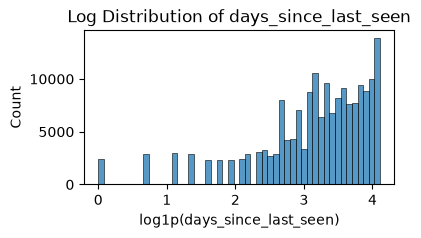

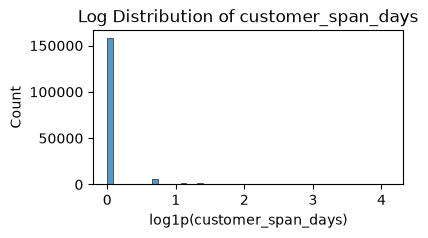

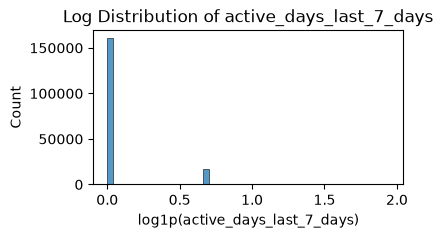

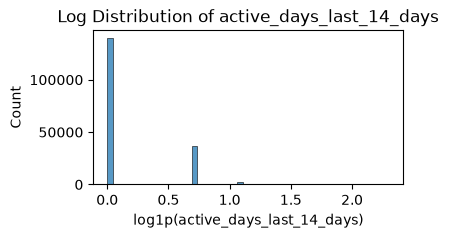

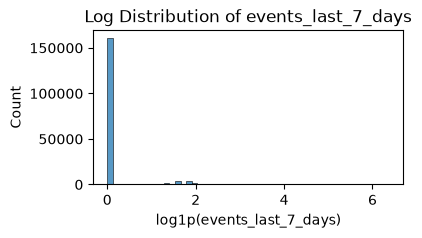

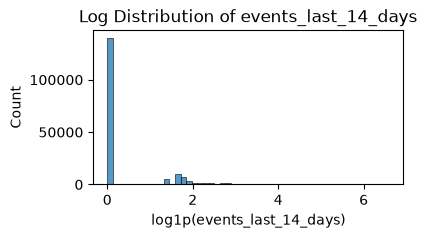

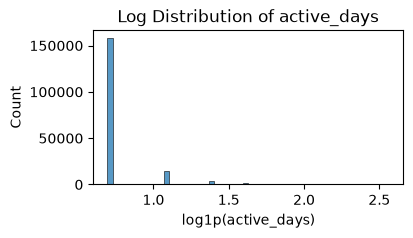

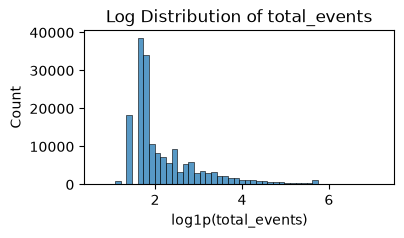

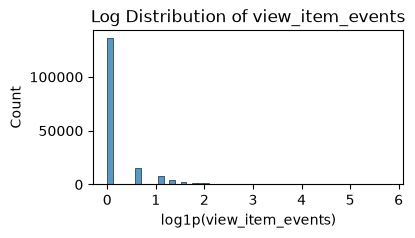

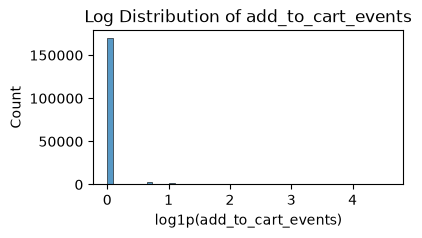

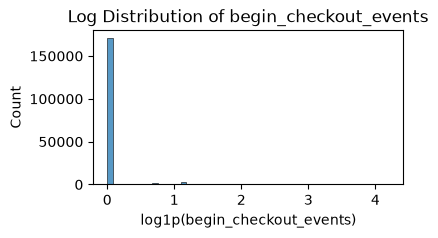

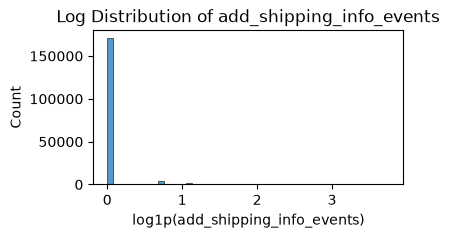

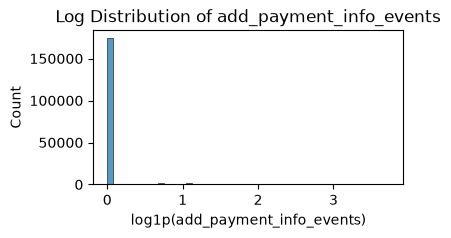

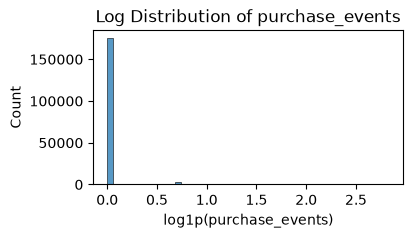

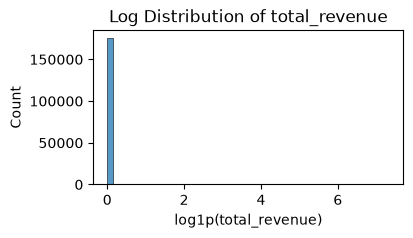

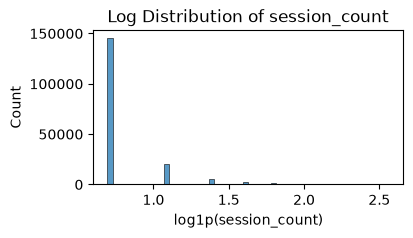

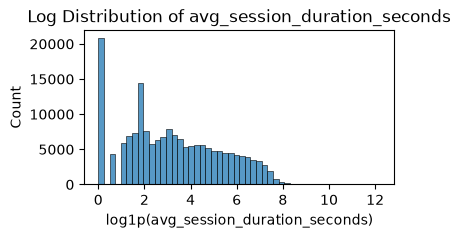

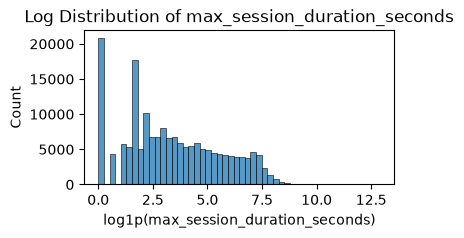

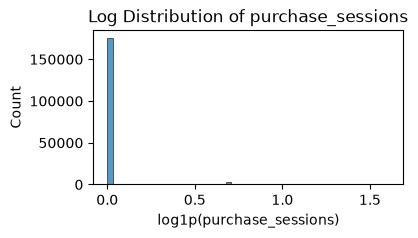

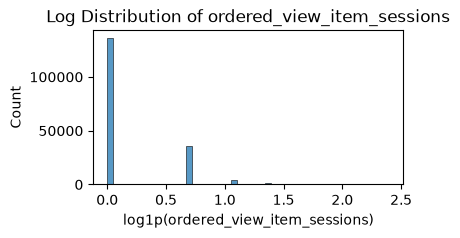

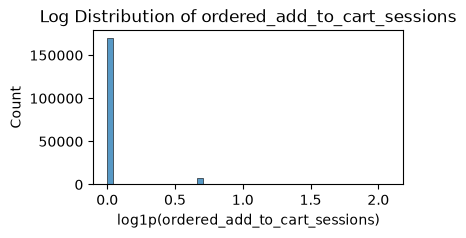

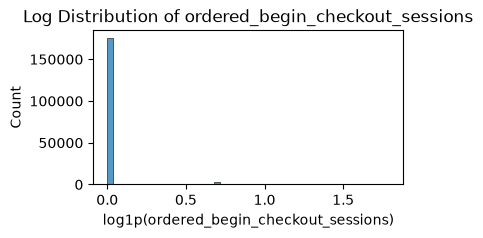

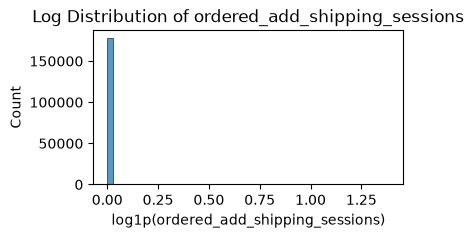

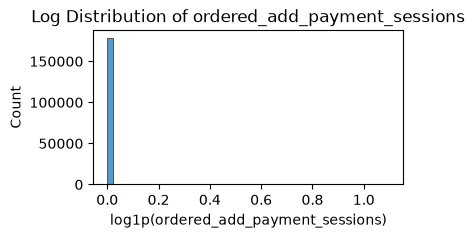

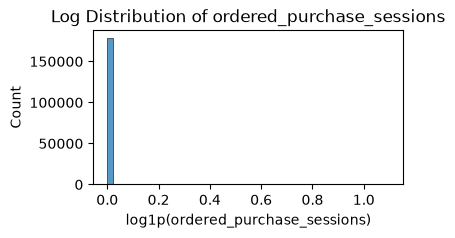

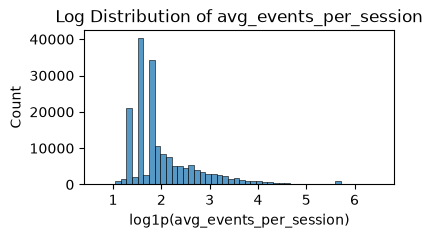

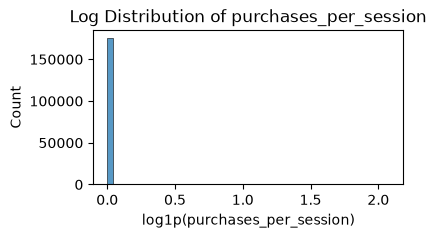

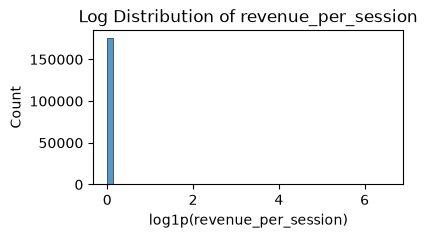

In [6]:
# visualize distributions of numeric columns

for col in numeric_cols:
    plt.figure(figsize=(4, 2))
    sns.histplot(np.log1p(df[col]), bins=50)
    plt.title(f"Log Distribution of {col}")
    plt.xlabel(f"log1p({col})")
    plt.ylabel("Count")
    plt.show()

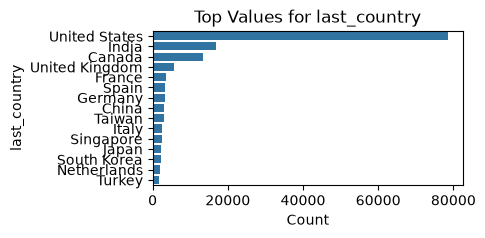

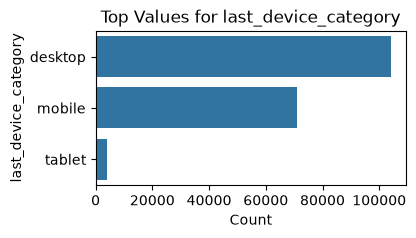

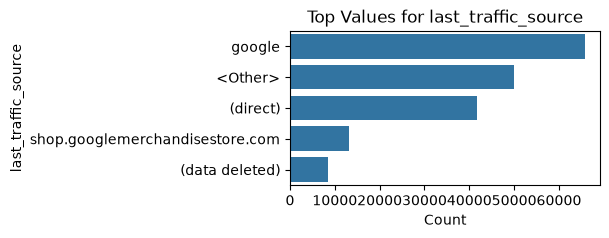

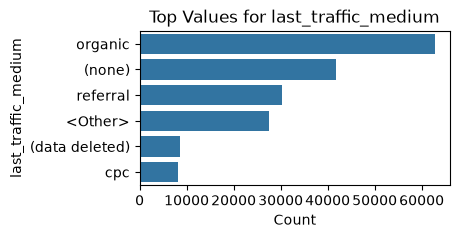

In [8]:
# visualize distributions of categorical columns

for col in categorical_cols:
    plt.figure(figsize=(4, 2))
    top_values = df[col].value_counts().head(15)

    sns.barplot(
        x=top_values.values,
        y=top_values.index
    )

    plt.title(f"Top Values for {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()

Feature distributions show strong right skew and sparsity (typical of ecommerce data). Most users have only one active day or session during the observation window, while a smaller group has higher engagement. Recency features are also sparse. 

In [ ]:
# define target variable and feature sets

target = "came_back_in_january"
exclude_cols = [
    "user_pseudo_id",
    "first_seen_date",
    "last_seen_date",
    "came_back_in_january",
    "purchased_in_january"
    ]
feature_cols = [col for col in df.columns if col not in exclude_cols]
X = df[feature_cols]
y = df[target].astype(int)

categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_features = X.select_dtypes(include=["number", "Int64", "float64", "int64"]).columns.tolist()

X.shape, y.shape, len(numeric_features), len(categorical_features)

((179085, 32), (179085,), 28, 4)

In [ ]:
# train-test split (stratified)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=33,
    stratify=y
)
y_train.mean(), y_test.mean()

(np.float64(0.02077923890889801), np.float64(0.02077225898316442))

The target is highly imbalanced, with returning users making up about 2.1% of both the training and test sets. Stratifying the split preserves the same class balance in both samples.

In [15]:
# establish baseline model (predicting all zeros)

baseline_pred = np.zeros_like(y_test)
print(classification_report(y_test, baseline_pred, zero_division=0))
confusion_matrix(y_test, baseline_pred)

              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     35073
         1.0       0.00      0.00      0.00       744

    accuracy                           0.98     35817
   macro avg       0.49      0.50      0.49     35817
weighted avg       0.96      0.98      0.97     35817



array([[35073,     0],
       [  744,     0]])

In [27]:
# build logistic regression model with preprocessing for numeric and categorical features

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)
log_reg = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(class_weight="balanced", max_iter=1000)),
    ]
)
log_reg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](32,)","['days_since_last_seen','customer_span_days','active_days_last_7_days',..., 'avg_events_per_session','purchases_per_session','revenue_per_session']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,32
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specified

In [28]:
# evaluate logistic regression model

log_reg_pred = log_reg.predict(X_test)
log_reg_proba = log_reg.predict_proba(X_test)[:, 1]
print(classification_report(y_test, log_reg_pred, zero_division=0))
confusion_matrix(y_test, log_reg_pred)

              precision    recall  f1-score   support

         0.0       0.99      0.79      0.88     35073
         1.0       0.06      0.65      0.11       744

    accuracy                           0.79     35817
   macro avg       0.53      0.72      0.50     35817
weighted avg       0.97      0.79      0.86     35817



array([[27774,  7299],
       [  262,   482]])

In [30]:
# evaluate model performance using ROC AUC and PR AUC 

print("ROC AUC:", roc_auc_score(y_test, log_reg_proba))
print("PR AUC:", average_precision_score(y_test, log_reg_proba))

ROC AUC: 0.7986738834118332
PR AUC: 0.15058821585990748


The model achieves moderate recall for the returning-user class, correctly identifying 65% of users who actually came back in January. However, precision is low at 6%, meaning most users predicted as returners did not actually return.

The ROC AUC of 0.80 suggests the model has meaningful ability to separate returning users from non-returning users. Because the positive class is rare, PR AUC is especially important; the PR AUC of 0.15 is well above the baseline return rate of about 0.02, indicating that the model ranks returning users better than random selection.

Overall, this model is more appropriate for broad re-engagement audience scoring than for high-confidence individual prediction.

In [31]:
# build random forest model

rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=33,
                n_jobs=-1,
            ),
        ),
    ]
)

rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](32,)","['days_since_last_seen','customer_span_days','active_days_last_7_days',..., 'avg_events_per_session','purchases_per_session','revenue_per_session']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,32
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specified

In [32]:
# evaluate random forest model

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred, zero_division=0))
print(confusion_matrix(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_proba))
print("PR AUC:", average_precision_score(y_test, rf_proba))

              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99     35073
         1.0       0.19      0.11      0.14       744

    accuracy                           0.97     35817
   macro avg       0.59      0.55      0.56     35817
weighted avg       0.96      0.97      0.97     35817

[[34736   337]
 [  663    81]]
ROC AUC: 0.7894797149662348
PR AUC: 0.09664698247456155


The random forest model is more conservative than logistic regression at the default threshold. It produces fewer positive predictions and achieves higher precision at 19%, but recall falls to 11%, meaning it misses most returning users.

Its ROC AUC is similar to logistic regression, but its PR AUC is lower. Because this is a rare-class problem, the lower PR AUC suggests that random forest is less effective at ranking likely returners in this setup.

In [34]:
# build gradient boosting model

gb = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=200,
                class_weight="balanced",
                random_state=33,
            ),
        ),
    ]
)
gb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](32,)","['days_since_last_seen','customer_span_days','active_days_last_7_days',..., 'avg_events_per_session','purchases_per_session','revenue_per_session']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,32
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specified

In [ ]:
# evaluate gradient boosting model

gb_pred = gb.predict(X_test)
gb_proba = gb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, gb_pred, zero_division=0))
print(confusion_matrix(y_test, gb_pred))
print("ROC AUC:", roc_auc_score(y_test, gb_proba))
print("PR AUC:", average_precision_score(y_test, gb_proba))


              precision    recall  f1-score   support

         0.0       0.99      0.81      0.89     35073
         1.0       0.07      0.70      0.13       744

    accuracy                           0.81     35817
   macro avg       0.53      0.76      0.51     35817
weighted avg       0.97      0.81      0.88     35817

[[28430  6643]
 [  223   521]]
ROC AUC: 0.8262420561231889
PR AUC: 0.17734517748739434


Gradient boosting produced the strongest overall ranking performance among the models tested. It identified 70% of returning users and achieved the highest ROC AUC and PR AUC. Because the positive class is rare, the PR AUC of 0.177 is especially important: it is substantially higher than the baseline return rate of about 0.021.

However, precision remains low at the default threshold, so the model should still be interpreted as an audience-scoring tool rather than a high-confidence individual prediction model.

In [36]:
# threshold tuning for gradient boosting model

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

threshold_results = []

for threshold in thresholds:
    preds = (gb_proba >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "predicted_positives": preds.sum()
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,precision,recall,f1,predicted_positives
0,0.1,0.022204,0.995968,0.043439,33373
1,0.2,0.030964,0.919355,0.059911,22090
2,0.3,0.044473,0.852151,0.084533,14256
3,0.4,0.054105,0.771505,0.101119,10609
4,0.5,0.072725,0.700269,0.131765,7164
5,0.6,0.091646,0.607527,0.159267,4932
6,0.7,0.120567,0.502688,0.194488,3102
7,0.8,0.177239,0.383065,0.242347,1608
8,0.9,0.302966,0.192204,0.235197,472


Threshold tuning shows a clear precision-recall tradeoff. At low thresholds, the model captures most returning users but selects a very large audience with low precision. At higher thresholds, the model produces a smaller, more targeted audience with higher precision.

A threshold around 0.8 provides the strongest F1 score in this grid, identifying 38% of returning users while improving precision to 18%.

In [ ]:
# cross-validation for gradient boosting model with .5 threshold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=33
)
cv_results = cross_validate(
    gb,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision",
        "f1": "f1",
    },
    n_jobs=-1
)
pd.DataFrame(cv_results).agg(["mean", "std"]).T

,mean,std
fit_time,16.426548,0.969546
score_time,0.765833,0.075198
test_roc_auc,0.828348,0.002912
test_pr_auc,0.168921,0.014930
test_f1,0.130854,0.002132


Cross-validation was used to evaluate whether the gradient boosting model's performance was stable across different training folds. The model achieved an average ROC AUC of 0.828 with very low variation across folds, suggesting stable ranking performance.

The average PR AUC was 0.169, which is substantially higher than the baseline return rate of about 2.1%. PR AUC varies more than ROC AUC because the positive class is rare, but the results still indicate that the model consistently identifies signal beyond random selection.

The cross-validated F1 score is based on the default 0.5 threshold, so it should be interpreted separately from the later threshold-tuning results.

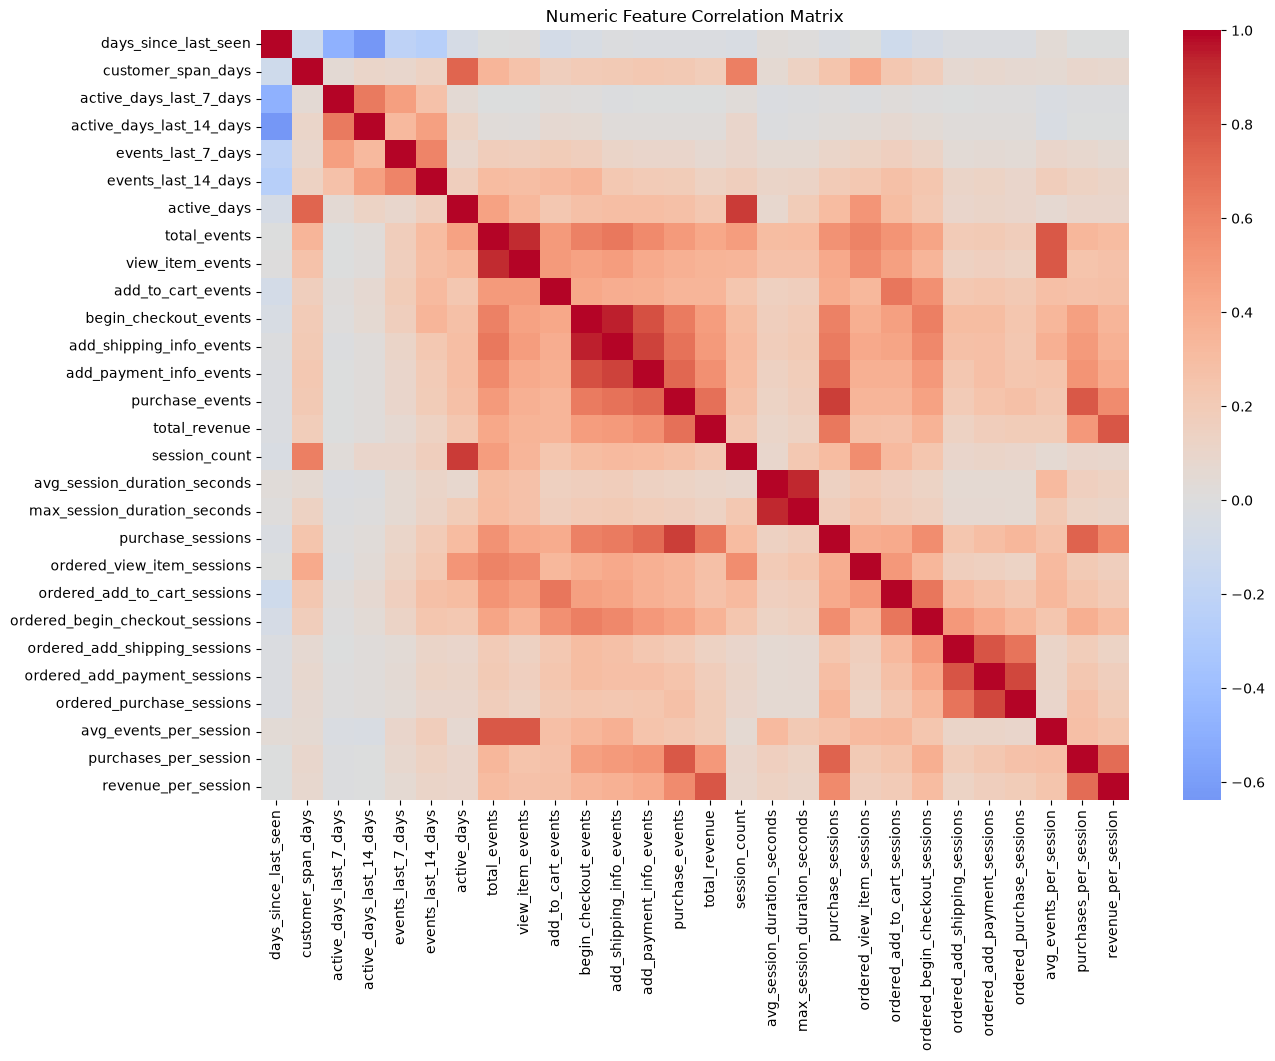

In [42]:
# correlation matrix for numeric features

corr = X[numeric_features].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Numeric Feature Correlation Matrix")
plt.show()

In [43]:
corr_pairs = (
    corr.abs()
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

corr_pairs.head(25)

begin_checkout_events          add_shipping_info_events           0.947340
avg_session_duration_seconds   max_session_duration_seconds       0.935045
total_events                   view_item_events                   0.922857
active_days                    session_count                      0.872785
purchase_events                purchase_sessions                  0.870092
add_shipping_info_events       add_payment_info_events            0.848432
ordered_add_payment_sessions   ordered_purchase_sessions          0.836373
begin_checkout_events          add_payment_info_events            0.804223
ordered_add_shipping_sessions  ordered_add_payment_sessions       0.789221
total_revenue                  revenue_per_session                0.776817
view_item_events               avg_events_per_session             0.774809
purchase_events                purchases_per_session              0.773429
total_events                   avg_events_per_session             0.770376
purchase_sessions        

The correlation analysis shows substantial overlap among several numeric behavior features. Funnel-step counts are strongly correlated with one another, session-duration features are highly correlated, and purchase/revenue fields carry similar information. This is expected in ecommerce clickstream data because users with more activity tend to generate more sessions, more product views, and more downstream funnel events.

Because many features are redundant, a reduced model can test whether most predictive signal is captured by a smaller set of recency, engagement, session-quality, and prior-purchase features.

In [45]:
# reduce features based on correlation

reduced_numeric_features = [
    "days_since_last_seen",
    "customer_span_days",
    "events_last_14_days",
    "total_events",
    "view_item_events",
    "session_count",
    "max_session_duration_seconds",
    "begin_checkout_events",
    "purchase_events",
    "total_revenue",
]
reduced_categorical_features = categorical_features
reduced_feature_cols = reduced_numeric_features + reduced_categorical_features


In [ ]:
# train reduced gradient boosting model

X_train_reduced = X_train[reduced_feature_cols]
X_test_reduced = X_test[reduced_feature_cols]
reduced_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), reduced_numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), reduced_categorical_features),
    ]
)
gb_reduced = Pipeline(
    steps=[
        ("preprocessor", reduced_preprocessor),
        (
            "model",
            HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=200,
                class_weight="balanced",
                random_state=33,
            ),
        ),
    ]
)
gb_reduced.fit(X_train_reduced, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['days_since_last_seen','customer_span_days','events_last_14_days',..., 'last_device_category','last_traffic_source','last_traffic_medium']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns 

In [ ]:
# evaluate reduced gradient boosting model

gb_reduced_pred = gb_reduced.predict(X_test_reduced)
gb_reduced_proba = gb_reduced.predict_proba(X_test_reduced)[:, 1]

print(classification_report(y_test, gb_reduced_pred, zero_division=0))
print(confusion_matrix(y_test, gb_reduced_pred))
print("ROC AUC:", roc_auc_score(y_test, gb_reduced_proba))
print("PR AUC:", average_precision_score(y_test, gb_reduced_proba))

              precision    recall  f1-score   support

         0.0       0.99      0.81      0.89     35073
         1.0       0.07      0.70      0.13       744

    accuracy                           0.81     35817
   macro avg       0.53      0.75      0.51     35817
weighted avg       0.97      0.81      0.88     35817

[[28448  6625]
 [  226   518]]
ROC AUC: 0.8274747960398419
PR AUC: 0.1762183313957579


The reduced gradient boosting model performs nearly identically to the full model. ROC AUC remains around 0.83 and PR AUC remains around 0.18, indicating that most predictive signal is captured by a smaller set of recency, engagement, session-quality, funnel, purchase, and categorical features.

This suggests that many of the removed variables were redundant with the retained features. The reduced model is easier to interpret while preserving essentially the same ranking performance.

In [48]:
# threshold tuning for reduced gradient boosting model

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

threshold_results = []

for threshold in thresholds:
    preds = (gb_reduced_proba >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "predicted_positives": preds.sum()
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,precision,recall,f1,predicted_positives
0,0.1,0.022048,0.994624,0.043140,33563
1,0.2,0.031428,0.924731,0.060791,21891
2,0.3,0.044715,0.857527,0.084999,14268
3,0.4,0.054318,0.776882,0.101537,10641
4,0.5,0.072519,0.696237,0.131355,7143
5,0.6,0.092658,0.595430,0.160362,4781
6,0.7,0.123741,0.512097,0.199320,3079
7,0.8,0.178707,0.379032,0.242894,1578
8,0.9,0.288889,0.192204,0.230831,495


Threshold tuning shows a clear precision-recall tradeoff. At lower thresholds, the model captures nearly all returning users but selects a very large audience with low precision. As the threshold increases, the model becomes more selective: precision improves, but recall decreases.

Among the tested thresholds, 0.8 provides the strongest F1 score. At this threshold, the model identifies 38% of returning users with 18% precision, selecting 1,578 users as likely returners. This is a more practical operating point than the default 0.5 threshold because it creates a smaller and more targeted audience.

A threshold of 0.9 produces higher precision at 29%, but recall falls to 19%, so it may be preferable only if the goal is a much smaller, higher-confidence audience.

In [49]:
# feature importance for reduced gradient boosting model

perm_importance = permutation_importance(
    gb_reduced,
    X_test_reduced,
    y_test,
    scoring="average_precision",
    n_repeats=5,
    random_state=33,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test_reduced.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std,
}).sort_values("importance_mean", ascending=False)

importance_df.head(15)


,feature,importance_mean,importance_std
0,days_since_last_seen,0.096139,0.005089
1,customer_span_days,0.062553,0.006864
3,total_events,0.035926,0.004203
4,view_item_events,0.018337,0.002309
5,session_count,0.015144,0.003623
6,max_session_duration_seconds,0.009483,0.000422
2,events_last_14_days,0.005119,0.000489
10,last_country,0.002157,0.000620
12,last_traffic_source,0.000950,0.000343
7,begin_checkout_events,0.000682,0.000762


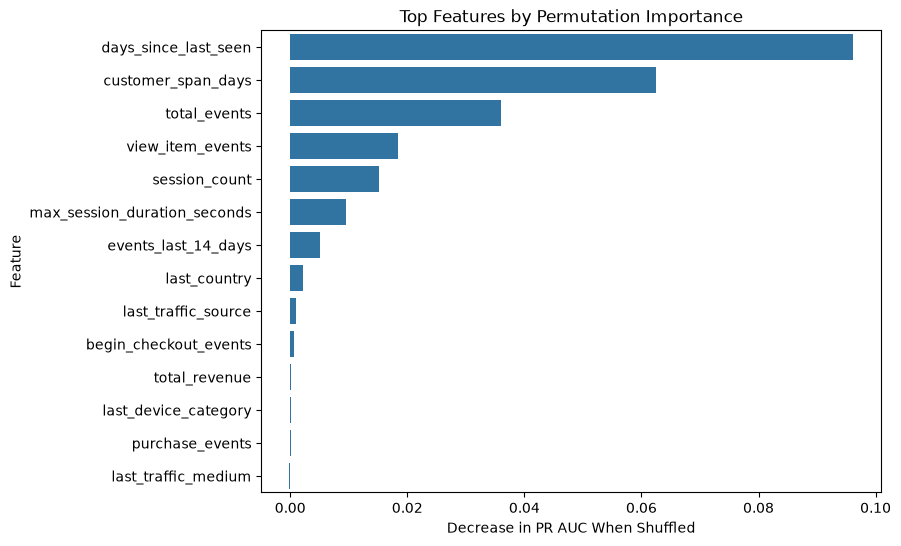

In [ ]:
# visualize top features by permutation importance

top_importance = importance_df.head(15)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=top_importance,
    x="importance_mean",
    y="feature"
)

plt.title("Top Features by Permutation Importance")
plt.xlabel("Decrease in PR AUC When Shuffled")
plt.ylabel("Feature")
plt.show()

Permutation importance measures how much model performance decreases when each feature is randomly shuffled. Features with larger decreases are more important because disrupting them harms the model's ability to rank likely returning users.

The most important features are recency and engagement measures, especially `days_since_last_seen`, `customer_span_days`, and total activity. This suggests that users who were active more recently and showed stronger engagement during the observation window were more likely to return in January.

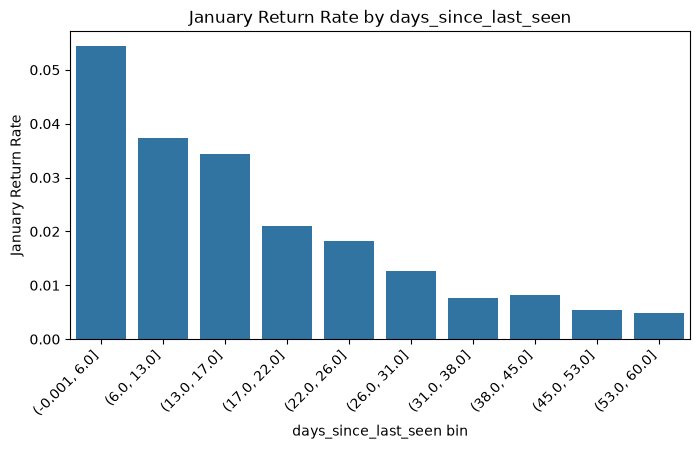

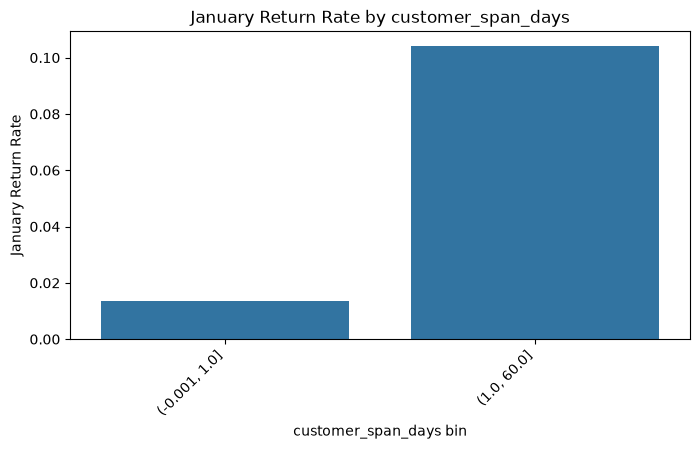

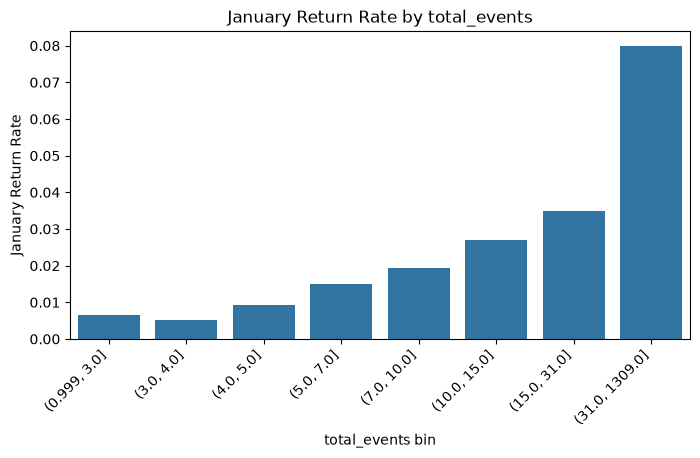

In [53]:
top_features = [
    "days_since_last_seen",
    "customer_span_days",
    "total_events",
]

for feature in top_features:
    feature_bins = pd.qcut(
        df[feature],
        q=10,
        duplicates="drop"
    )

    feature_return_rate = (
        df.groupby(feature_bins, observed=True)["came_back_in_january"]
        .mean()
        .reset_index(name="return_rate")
    )

    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=feature_return_rate,
        x=feature,
        y="return_rate"
    )

    plt.xticks(rotation=45, ha="right")
    plt.title(f"January Return Rate by {feature}")
    plt.xlabel(f"{feature} bin")
    plt.ylabel("January Return Rate")
    plt.show()

## Conclusions

This analysis built a binary classification model to predict whether users active in November-December 2020 returned in January 2021. Because only about 2.1% of users returned, this is a highly imbalanced classification problem, so PR AUC, recall, precision, and threshold tradeoffs are more informative than accuracy alone.

Gradient boosting performed best among the models tested. The full gradient boosting model achieved ROC AUC of 0.826 and PR AUC of 0.177, outperforming logistic regression and random forest on ranking performance.

Correlation analysis showed that many behavioral features were redundant, especially funnel-step, session-duration, and purchase/revenue variables. A reduced gradient boosting model using fewer recency, engagement, session-quality, funnel, purchase, and categorical features performed nearly identically to the full model, with ROC AUC of 0.827 and PR AUC of 0.176. This suggests that most predictive signal is captured by a smaller set of features.

Threshold tuning showed that the default 0.5 threshold is not the best operating point for this use case. A threshold of 0.8 produced the strongest F1 score among the tested thresholds, identifying 38% of returning users with 18% precision and selecting 1,578 users as likely returners.

Permutation importance showed that recency was the strongest predictor. `days_since_last_seen` was the most important feature by a large margin, followed by `customer_span_days`, `total_events`, `view_item_events`, and `session_count`. This suggests that recent activity and overall engagement are the strongest indicators of January return behavior.
The binned return-rate plots show clear directional relationships for the top features identified by permutation importance.

- `days_since_last_seen` is inversely related to January return rate. Users seen most recently before January had the highest return rate, while users whose last activity was farther in the past were much less likely to return.

- `customer_span_days` is positively related to return behavior. Users observed across more than one day in the November-December window had a much higher January return rate than users observed on only one day.

- `total_events` is also positively related to return behavior. Users with more total events during the observation window had progressively higher January return rates, suggesting that stronger engagement intensity is associated with future re-engagement.

Overall, the model is best interpreted as a re-engagement audience scoring tool rather than a high-confidence individual prediction model. It can help prioritize users who are more likely to return, but precision remains low because the positive class is rare.